# 🚗 Car Evaluation Classification Analysis
## XGBoost vs Random Forest Classifier dengan Metaheuristic Hyperparameter Tuning (PSO)

**Dataset:** Car Evaluation Database – UCI Machine Learning Repository (link: https://archive.ics.uci.edu/dataset/19/car+evaluation)

**Citation:**
Bohanec, M. (1988). Car Evaluation [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5JP48.

**Creator:** Marko Bohanec | **Tahun:** 1997  
**Target:** Klasifikasi kelayakan mobil → `unacc`, `acc`, `good`, `vgood`

---
### 📋 Pipeline Analisis:
1. **EDA** – Exploratory Data Analysis  
2. **Preprocessing** – Ordinal Encoding, SMOTE Balancing
3. **Hyperparameter Tuning** – Particle Swarm Optimization (PSO)  
4. **Pemodelan** – XGBoost & RF
5. **Evaluasi & Perbandingan** – Split 80:20 vs 70:30


## 1. Import Library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.inspection import permutation_importance

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


## 2. Load & Inpeksi Dataset

In [3]:
df = pd.read_csv('car.csv', sep=';')
print(f"Shape: {df.shape}")
print(f"Kolom: {list(df.columns)}")
df.head(10)

Shape: (1728, 7)
Kolom: ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'car_eval']


,buying,maint,doors,persons,lug_boot,safety,car_eval
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
5,vhigh,vhigh,2,2,med,high,unacc
6,vhigh,vhigh,2,2,big,low,unacc
7,vhigh,vhigh,2,2,big,med,unacc
8,vhigh,vhigh,2,2,big,high,unacc
9,vhigh,vhigh,2,4,small,low,unacc


In [4]:
print("=== INFO ===")
df.info()
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())
print(f"\nDuplikat: {df.duplicated().sum()}")
print("\n=== DISTRIBUSI KELAS ===")
print(df['car_eval'].value_counts())

=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   str  
 1   maint     1728 non-null   str  
 2   doors     1728 non-null   str  
 3   persons   1728 non-null   str  
 4   lug_boot  1728 non-null   str  
 5   safety    1728 non-null   str  
 6   car_eval  1728 non-null   str  
dtypes: str(7)
memory usage: 94.6 KB

=== MISSING VALUES ===
buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
car_eval    0
dtype: int64

Duplikat: 0

=== DISTRIBUSI KELAS ===
car_eval
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)

### 3.1 Distribusi Kelas Target
⚠️ Dataset sangat **tidak seimbang** – kelas `unacc` mendominasi 70%.

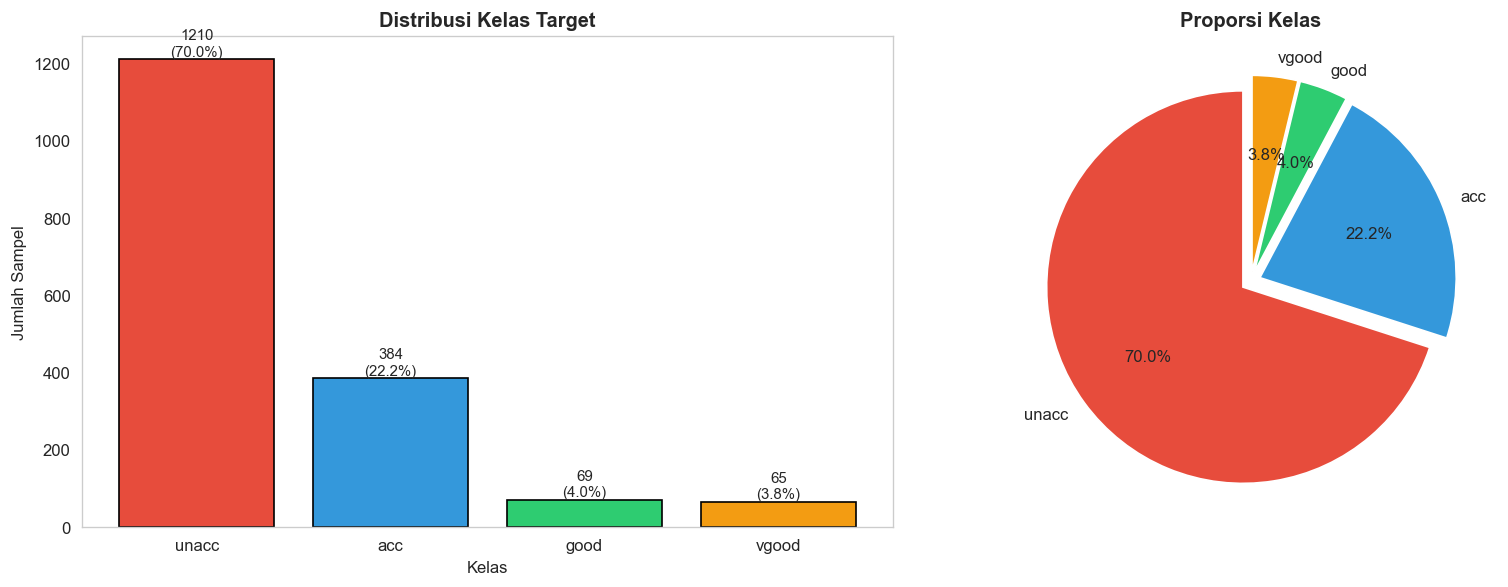

In [5]:
colors = ['#e74c3c','#3498db','#2ecc71','#f39c12']
class_counts = df['car_eval'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar Chart
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Distribusi Kelas Target', fontweight='bold')
axes[0].set_xlabel('Kelas'); axes[0].set_ylabel('Jumlah Sampel')
axes[0].grid(False)  # <-- Menghapus/menonaktifkan grid pada grafik batang

for bar, cnt in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{cnt}\n({cnt/len(df)*100:.1f}%)', ha='center', fontsize=9)

# Plot 2: Pie Chart
axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.1f%%', colors=colors, explode=[0.05]*4, startangle=90)
axes[1].set_title('Proporsi Kelas', fontweight='bold')
axes[1].grid(False)  # <-- Memastikan tidak ada sisa grid yang aktif di pie chart

plt.tight_layout()
plt.show()


### 3.2 Distribusi Fitur Input
Semua fitur bersifat **kategorikal ordinal** dengan distribusi yang seragam.

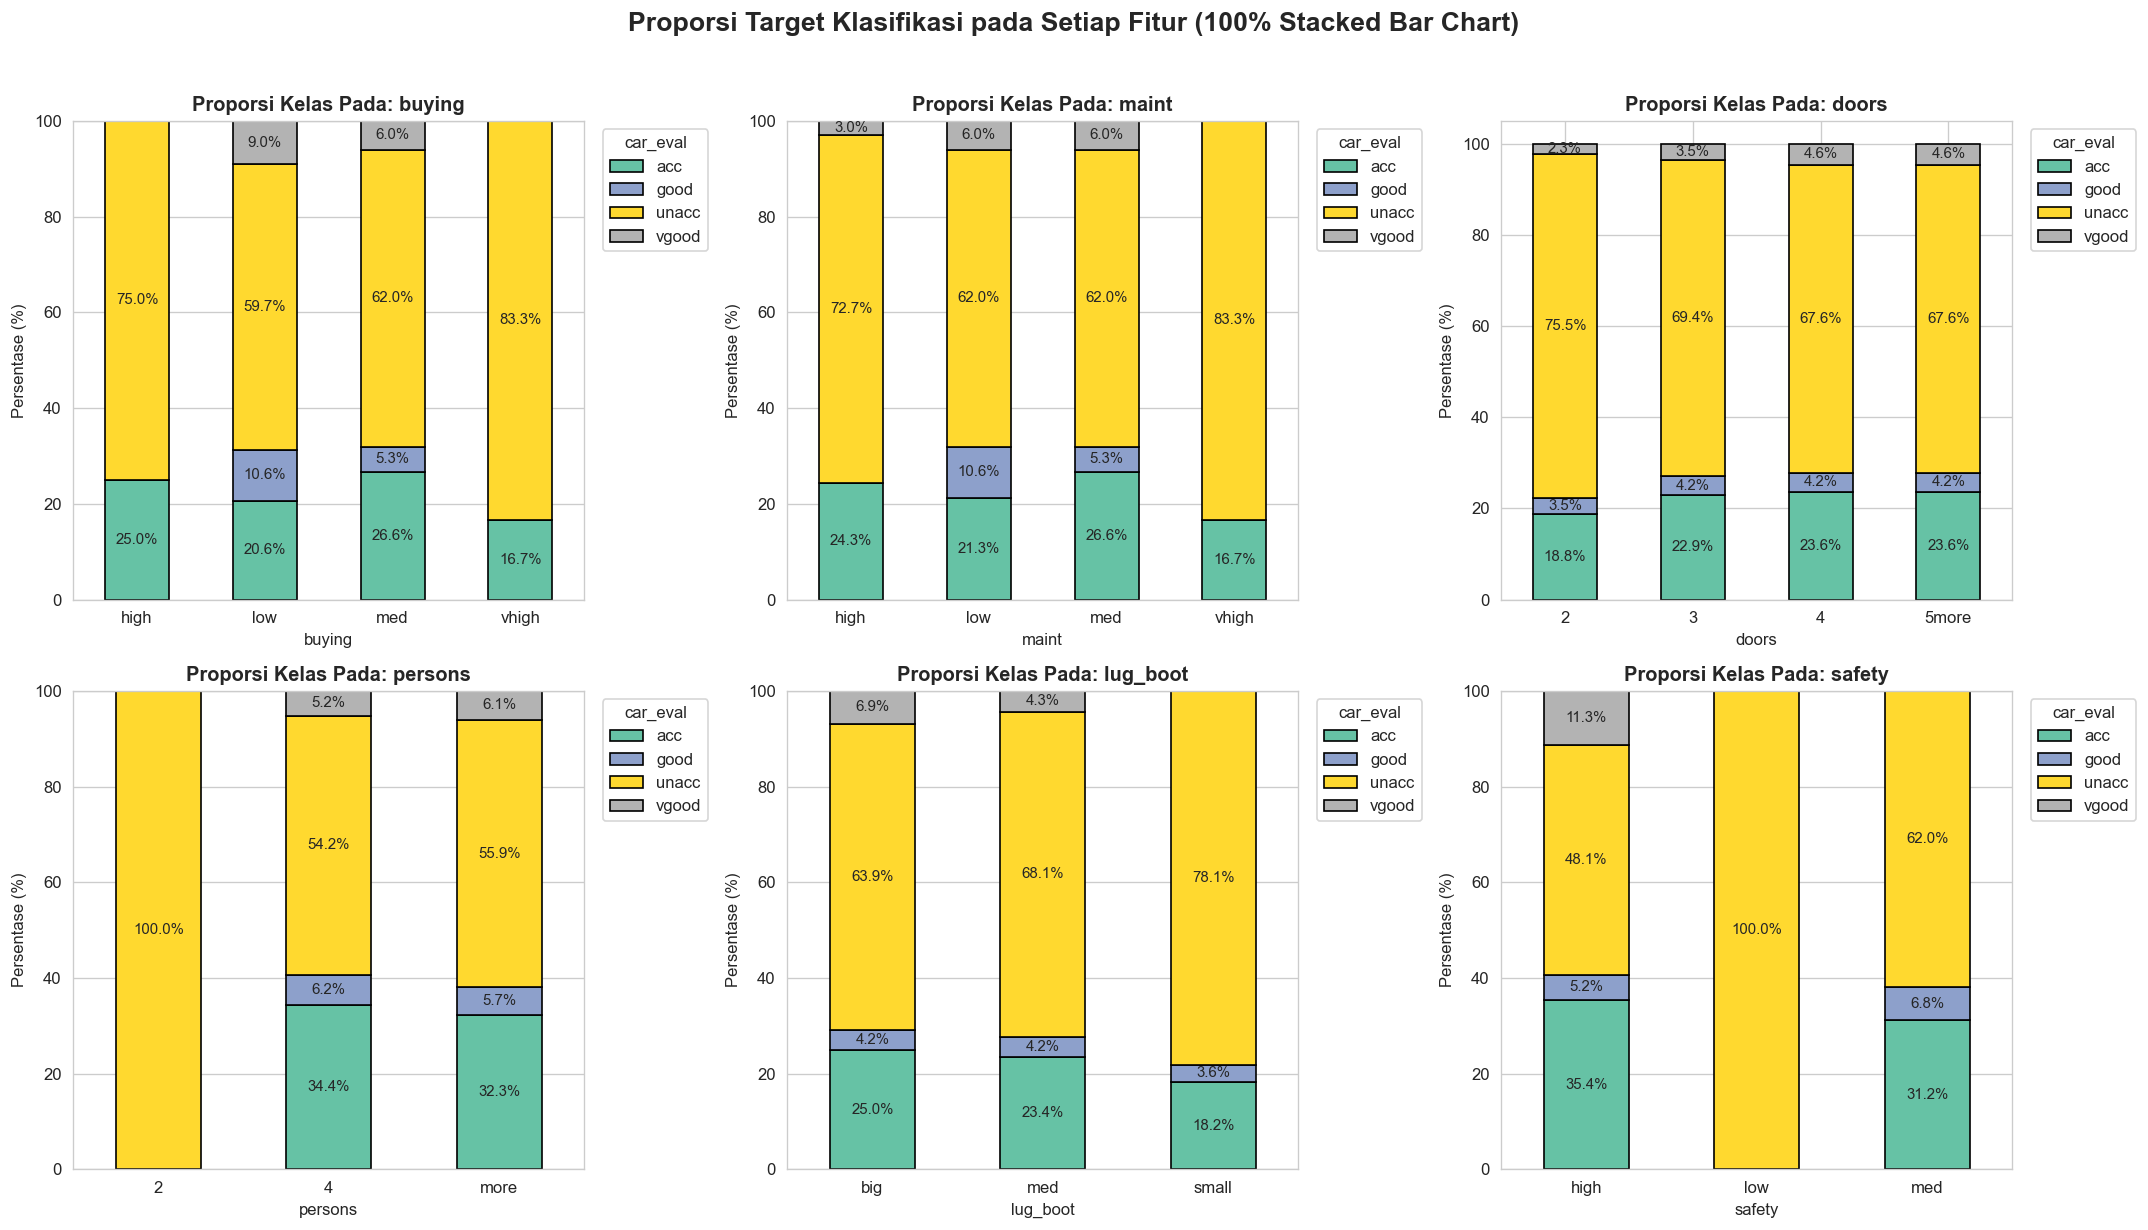

In [6]:
features = ['buying','maint','doors','persons','lug_boot','safety']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    # Menghitung proporsi (%) silang antara dari tiap fitur terhadap target 'car_eval'
    df_pct = pd.crosstab(df[feat], df['car_eval'], normalize='index') * 100
    
    # Membuat plot stacked bar
    df_pct.plot(kind='bar', stacked=True, ax=axes[i], colormap='Set2', edgecolor='black')
    
    axes[i].set_title(f'Proporsi Kelas Pada: {feat}', fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Persentase (%)')
    
    # Membuat label x axis agar tidak miring (horizontal)
    axes[i].tick_params(axis='x', rotation=0)
    
    # Menambahkan anotasi persentase di tiap potongan bar
    for c in axes[i].containers:
        # Tampilkan jika persentase lebih dari 0 untuk menghindari tumpang tindih
        labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
        axes[i].bar_label(c, labels=labels, label_type='center', fontsize=9)
        
    # Memindahkan legend agar tidak menutupi bar di dalam plot
    axes[i].legend(title='car_eval', bbox_to_anchor=(1.02, 1), loc='upper left')

# Tambahkan judul utama
plt.suptitle('Proporsi Target Klasifikasi pada Setiap Fitur (100% Stacked Bar Chart)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 3.3 Hubungan Fitur vs Target

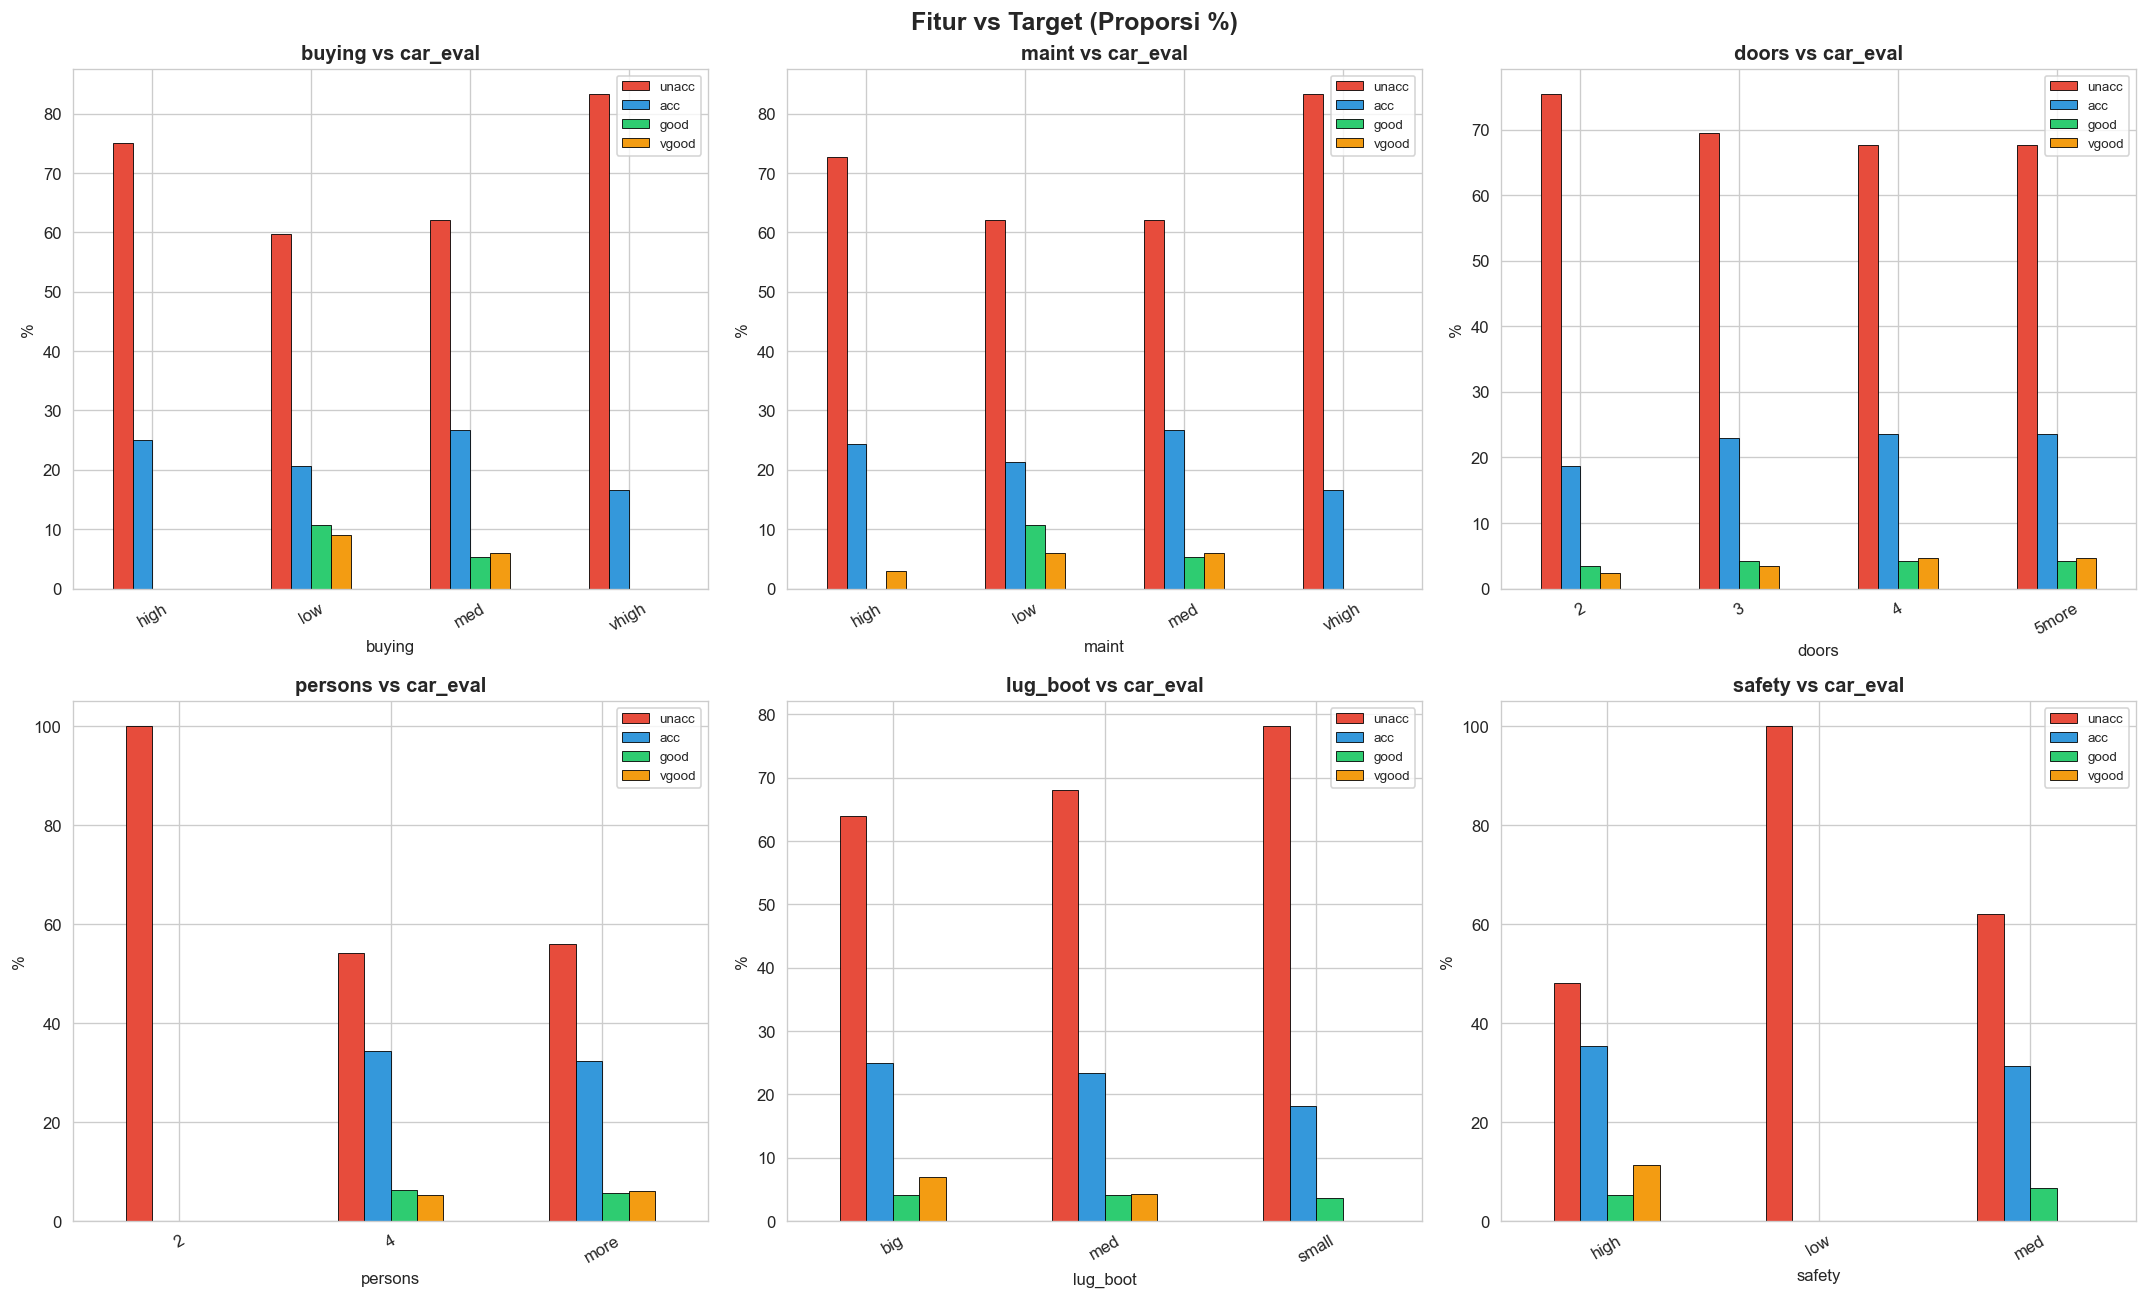

In [7]:
class_order = ['unacc','acc','good','vgood']
hue_palette = {'unacc':'#e74c3c','acc':'#3498db','good':'#2ecc71','vgood':'#f39c12'}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
for i, feat in enumerate(features):
    ct = pd.crosstab(df[feat], df['car_eval'])
    ct = ct.reindex(columns=[c for c in class_order if c in ct.columns])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=axes[i], color=[hue_palette[c] for c in ct_pct.columns],
                edgecolor='black', lw=0.5)
    axes[i].set_title(f'{feat} vs car_eval', fontweight='bold')
    axes[i].set_xlabel(feat); axes[i].set_ylabel('%'); axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='x', rotation=30)
plt.suptitle('Fitur vs Target (Proporsi %)', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Preprocessing

### 4.1 Ordinal Encoding
Urutan nilai dikodekan sesuai urutan semantik domain (e.g., low < med < high < vhigh).

In [8]:
ordinal_mappings = {
    'buying'  : ['low','med','high','vhigh'],
    'maint'   : ['low','med','high','vhigh'],
    'doors'   : ['2','3','4','5more'],
    'persons' : ['2','4','more'],
    'lug_boot': ['small','med','big'],
    'safety'  : ['low','med','high'],
}
target_mapping = {'unacc':0,'acc':1,'good':2,'vgood':3}

df_proc = df.copy()
enc = OrdinalEncoder(categories=[ordinal_mappings[f] for f in features])
df_proc[features] = enc.fit_transform(df_proc[features])
df_proc['car_eval'] = df_proc['car_eval'].map(target_mapping)

X = df_proc[features].values
y = df_proc['car_eval'].values

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Distribusi: {dict(zip(*np.unique(y, return_counts=True)))}")
df_proc.head(20)

X shape: (1728, 6), y shape: (1728,)
Distribusi: {np.int64(0): np.int64(1210), np.int64(1): np.int64(384), np.int64(2): np.int64(69), np.int64(3): np.int64(65)}


,buying,maint,doors,persons,lug_boot,safety,car_eval
0,3.0,3.0,0.0,0.0,0.0,0.0,0
1,3.0,3.0,0.0,0.0,0.0,1.0,0
2,3.0,3.0,0.0,0.0,0.0,2.0,0
3,3.0,3.0,0.0,0.0,1.0,0.0,0
4,3.0,3.0,0.0,0.0,1.0,1.0,0
5,3.0,3.0,0.0,0.0,1.0,2.0,0
6,3.0,3.0,0.0,0.0,2.0,0.0,0
7,3.0,3.0,0.0,0.0,2.0,1.0,0
8,3.0,3.0,0.0,0.0,2.0,2.0,0
9,3.0,3.0,0.0,1.0,0.0,0.0,0


### 4.2 Data Splitting (80:20 & 70:30)

In [9]:
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)

print('Split 80:20 → Train:', X_train_80.shape[0], '| Test:', X_test_80.shape[0])
print('Split 70:30 → Train:', X_train_70.shape[0], '| Test:', X_test_70.shape[0])

Split 80:20 → Train: 1382 | Test: 346
Split 70:30 → Train: 1209 | Test: 519


### 4.3 Data Balancing dengan SMOTE
SMOTE (Synthetic Minority Over-sampling Technique) mensintesis sampel baru untuk kelas minoritas.

=== HASIL SMOTE ===
Split 80:20 Sebelum: {np.int64(0): np.int64(968), np.int64(1): np.int64(307), np.int64(2): np.int64(55), np.int64(3): np.int64(52)}
Split 80:20 Setelah : {np.int64(0): np.int64(968), np.int64(1): np.int64(968), np.int64(2): np.int64(968), np.int64(3): np.int64(968)}

Split 70:30 Sebelum: {np.int64(0): np.int64(847), np.int64(1): np.int64(269), np.int64(2): np.int64(48), np.int64(3): np.int64(45)}
Split 70:30 Setelah : {np.int64(0): np.int64(847), np.int64(1): np.int64(847), np.int64(2): np.int64(847), np.int64(3): np.int64(847)}


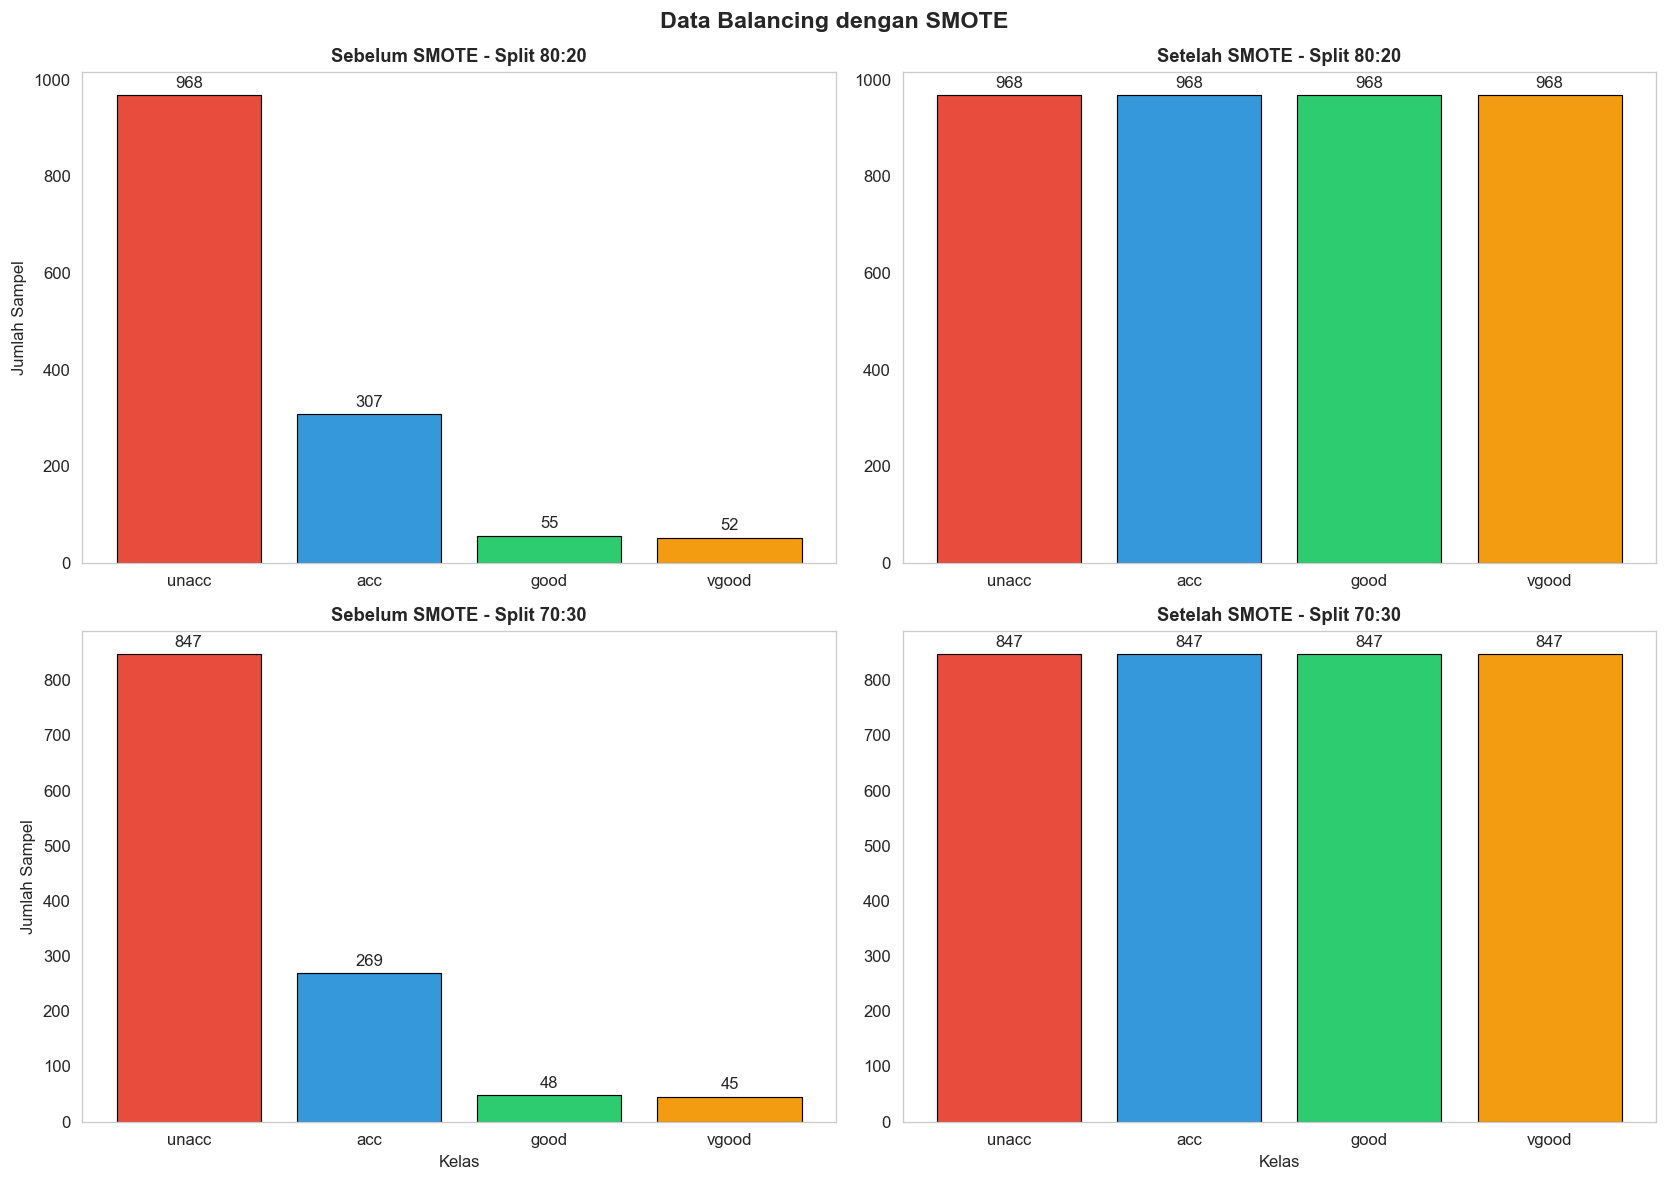

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# ── SMOTE ──────────────────────────────────────────────────────────────
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)

X_train_80_bal, y_train_80_bal = smote.fit_resample(X_train_80, y_train_80)
X_train_70_bal, y_train_70_bal = smote.fit_resample(X_train_70, y_train_70)

print('=== HASIL SMOTE ===')
print('Split 80:20 Sebelum:', dict(zip(*np.unique(y_train_80,     return_counts=True))))
print('Split 80:20 Setelah :', dict(zip(*np.unique(y_train_80_bal, return_counts=True))))
print()
print('Split 70:30 Sebelum:', dict(zip(*np.unique(y_train_70,     return_counts=True))))
print('Split 70:30 Setelah :', dict(zip(*np.unique(y_train_70_bal, return_counts=True))))

# ── VISUALISASI ─────────────────────────────────────────────────────────
bar_colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']

# Balik mapping: {0:'unacc', 1:'acc', 2:'good', 3:'vgood'}
target_mapping  = {'unacc': 0, 'acc': 1, 'good': 2, 'vgood': 3}
reverse_mapping = {v: k for k, v in target_mapping.items()}

def get_counts_labeled(y):
    """Ambil counts dan konversi angka → nama kelas."""
    nums, counts = np.unique(y, return_counts=True)
    labels = [reverse_mapping.get(n, str(n)) for n in nums]
    return labels, list(counts)

def create_bar_plot(ax, labels, counts, title, show_ylabel=False, show_xlabel=False):
    colors = [bar_colors[i % len(bar_colors)] for i in range(len(labels))]
    bars = ax.bar(labels, counts, color=colors, edgecolor='black', linewidth=0.7)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.grid(False)  # ← hapus gridline
    if show_ylabel:
        ax.set_ylabel('Jumlah Sampel')
    if show_xlabel:
        ax.set_xlabel('Kelas')
    max_val = max(counts) if max(counts) > 0 else 1
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + max_val * 0.01,
                str(int(h)), ha='center', va='bottom', fontsize=10)

# Siapkan data
lab_80,     cnt_80     = get_counts_labeled(y_train_80)
lab_80_bal, cnt_80_bal = get_counts_labeled(y_train_80_bal)
lab_70,     cnt_70     = get_counts_labeled(y_train_70)
lab_70_bal, cnt_70_bal = get_counts_labeled(y_train_70_bal)

# Plot 2x2
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
fig.suptitle('Data Balancing dengan SMOTE', fontsize=14, fontweight='bold')

create_bar_plot(axes[0, 0], lab_80,     cnt_80,     'Sebelum SMOTE - Split 80:20', show_ylabel=True)
create_bar_plot(axes[0, 1], lab_80_bal, cnt_80_bal, 'Setelah SMOTE - Split 80:20')
create_bar_plot(axes[1, 0], lab_70,     cnt_70,     'Sebelum SMOTE - Split 70:30', show_ylabel=True, show_xlabel=True)
create_bar_plot(axes[1, 1], lab_70_bal, cnt_70_bal, 'Setelah SMOTE - Split 70:30', show_xlabel=True)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()


## 4. Hyperparameter Tuning – Particle Swarm Optimization (PSO)

**PSO** adalah algoritma metaheuristik terinspirasi perilaku kawanan burung.  
Setiap **partikel** merepresentasikan satu set hyperparameter dan bergerak menuju solusi terbaik berdasarkan:
- **Personal Best (pb)** – posisi terbaik partikel itu sendiri  
- **Global Best (gb)** – posisi terbaik di seluruh kawanan  

**Update velocity:** `v = w·v + c1·r1·(pb - x) + c2·r2·(gb - x)`  
**Update posisi:**  `x = x + v`


In [33]:
class Particle:
    def __init__(self, bounds):
        self.position = np.array([np.random.uniform(b[0],b[1]) for b in bounds])
        self.velocity = np.array([np.random.uniform(-abs(b[1]-b[0])*0.1,
                                                     abs(b[1]-b[0])*0.1) for b in bounds])
        self.best_position = self.position.copy()
        self.best_score = -np.inf

def pso_optimize(obj_fn, bounds, n_particles=8, n_iterations=12, w=0.7, c1=1.5, c2=1.5, verbose=True):
    """
    Particle Swarm Optimization untuk Hyperparameter Tuning
    
    Parameters
    ----------
    obj_fn      : callable, returns fitness score (higher = better)
    bounds      : list of (min, max) per dimensi
    n_particles : jumlah partikel
    n_iterations: jumlah iterasi
    w           : inertia weight
    c1          : cognitive coefficient
    c2          : social coefficient
    """
    particles = [Particle(bounds) for _ in range(n_particles)]
    gb_pos = particles[0].position.copy()
    gb_score = -np.inf
    history = []

    for it in range(n_iterations):
        for p in particles:
            s = obj_fn(p.position)
            if s > p.best_score:
                p.best_score = s
                p.best_position = p.position.copy()
            if s > gb_score:
                gb_score = s
                gb_pos = p.position.copy()

        for p in particles:
            r1,r2 = np.random.rand(len(bounds)), np.random.rand(len(bounds))
            p.velocity = (w * p.velocity
                         + c1*r1*(p.best_position - p.position)
                         + c2*r2*(gb_pos - p.position))
            for j,b in enumerate(bounds):
                vmax = abs(b[1]-b[0])*0.2
                p.velocity[j] = np.clip(p.velocity[j], -vmax, vmax)
            p.position = np.clip(p.position + p.velocity,
                                 [b[0] for b in bounds], [b[1] for b in bounds])
        history.append(gb_score)
        if verbose:
            print(f'  Iterasi {it+1:2d}/{n_iterations} | Best Score: {gb_score:.4f}')

    return gb_pos, gb_score, history


### 4.1 PSO Tuning – XGBoost

In [12]:
def xgb_obj(params, X_tr, y_tr):
    """Quick holdout evaluation for XGBoost (faster than CV)"""
    idx = np.random.permutation(len(y_tr))
    half = len(y_tr)//2
    m = XGBClassifier(
        n_estimators=int(params[0]), max_depth=int(params[1]),
        learning_rate=float(params[2]), subsample=float(params[3]),
        colsample_bytree=float(params[4]), min_child_weight=float(params[5]),
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    m.fit(X_tr[idx[:half]], y_tr[idx[:half]])
    return f1_score(y_tr[idx[half:]], m.predict(X_tr[idx[half:]]), average='weighted')

xgb_bounds = [
    (30, 200),    # n_estimators
    (2, 7),       # max_depth
    (0.05, 0.3),  # learning_rate
    (0.7, 1.0),   # subsample
    (0.7, 1.0),   # colsample_bytree
    (1, 8),       # min_child_weight
]

print("🔍 PSO XGBoost – Split 80:20")
xgb_best_80, xgb_score_80, xgb_hist_80 = pso_optimize(
    lambda p: xgb_obj(p, X_train_80_bal, y_train_80_bal), xgb_bounds, n_particles=8, n_iterations=12)

print("\n🔍 PSO XGBoost – Split 70:30")
xgb_best_70, xgb_score_70, xgb_hist_70 = pso_optimize(
    lambda p: xgb_obj(p, X_train_70_bal, y_train_70_bal), xgb_bounds, n_particles=8, n_iterations=12)

print(f"\n✅ XGB 80:20 Best Score: {xgb_score_80:.4f}")
print(f"   Params: n_est={int(xgb_best_80[0])}, depth={int(xgb_best_80[1])}, lr={xgb_best_80[2]:.3f}")
print(f"\n✅ XGB 70:30 Best Score: {xgb_score_70:.4f}")
print(f"   Params: n_est={int(xgb_best_70[0])}, depth={int(xgb_best_70[1])}, lr={xgb_best_70[2]:.3f}")

🔍 PSO XGBoost – Split 80:20
  Iterasi  1/12 | Best Score: 0.9912
  Iterasi  2/12 | Best Score: 0.9959
  Iterasi  3/12 | Best Score: 0.9959
  Iterasi  4/12 | Best Score: 0.9959
  Iterasi  5/12 | Best Score: 0.9959
  Iterasi  6/12 | Best Score: 0.9959
  Iterasi  7/12 | Best Score: 0.9959
  Iterasi  8/12 | Best Score: 0.9959
  Iterasi  9/12 | Best Score: 0.9974
  Iterasi 10/12 | Best Score: 0.9974
  Iterasi 11/12 | Best Score: 0.9974
  Iterasi 12/12 | Best Score: 0.9974

🔍 PSO XGBoost – Split 70:30
  Iterasi  1/12 | Best Score: 0.9870
  Iterasi  2/12 | Best Score: 0.9941
  Iterasi  3/12 | Best Score: 0.9953
  Iterasi  4/12 | Best Score: 0.9953
  Iterasi  5/12 | Best Score: 0.9965
  Iterasi  6/12 | Best Score: 0.9965
  Iterasi  7/12 | Best Score: 0.9965
  Iterasi  8/12 | Best Score: 0.9965
  Iterasi  9/12 | Best Score: 0.9965
  Iterasi 10/12 | Best Score: 0.9965
  Iterasi 11/12 | Best Score: 0.9965
  Iterasi 12/12 | Best Score: 0.9970

✅ XGB 80:20 Best Score: 0.9974
   Params: n_est=90, de

### 4.2 PSO Tuning – Random Forest

In [13]:
def rf_obj(params, X_tr, y_tr):
    """Quick holdout evaluation for Random Forest"""
    idx = np.random.permutation(len(y_tr))
    half = len(y_tr) // 2
    m = RandomForestClassifier(
        n_estimators      = int(round(params[0])),
        max_depth         = int(round(params[1])),
        min_samples_split = int(round(params[2])),
        min_samples_leaf  = int(round(params[3])),
        random_state      = RANDOM_STATE,
        n_jobs            = -1
    )
    m.fit(X_tr[idx[:half]], y_tr[idx[:half]])
    return f1_score(y_tr[idx[half:]], m.predict(X_tr[idx[half:]]), average='weighted')

rf_bounds = [
    (50,  300),   # n_estimators  – jumlah pohon
    (3,   20),    # max_depth     – kedalaman pohon
    (2,   20),    # min_samples_split
    (1,   10),    # min_samples_leaf
]

print("🔍 PSO Random Forest – Split 80:20")
rf_best_80, rf_score_80, rf_hist_80 = pso_optimize(
    lambda p: rf_obj(p, X_train_80_bal, y_train_80_bal), rf_bounds, n_particles=8, n_iterations=12)

print("\n🔍 PSO Random Forest – Split 70:30")
rf_best_70, rf_score_70, rf_hist_70 = pso_optimize(
    lambda p: rf_obj(p, X_train_70_bal, y_train_70_bal), rf_bounds, n_particles=8, n_iterations=12)

print(f"\n✅ RF 80:20  Best Score : {rf_score_80:.4f}")
print(f"   n_estimators={int(round(rf_best_80[0]))}, max_depth={int(round(rf_best_80[1]))}, "
      f"min_split={int(round(rf_best_80[2]))}, min_leaf={int(round(rf_best_80[3]))}")
print(f"\n✅ RF 70:30  Best Score : {rf_score_70:.4f}")
print(f"   n_estimators={int(round(rf_best_70[0]))}, max_depth={int(round(rf_best_70[1]))}, "
      f"min_split={int(round(rf_best_70[2]))}, min_leaf={int(round(rf_best_70[3]))}")


🔍 PSO Random Forest – Split 80:20
  Iterasi  1/12 | Best Score: 0.9861
  Iterasi  2/12 | Best Score: 0.9891
  Iterasi  3/12 | Best Score: 0.9891
  Iterasi  4/12 | Best Score: 0.9907
  Iterasi  5/12 | Best Score: 0.9907
  Iterasi  6/12 | Best Score: 0.9917
  Iterasi  7/12 | Best Score: 0.9943
  Iterasi  8/12 | Best Score: 0.9943
  Iterasi  9/12 | Best Score: 0.9943
  Iterasi 10/12 | Best Score: 0.9943
  Iterasi 11/12 | Best Score: 0.9943
  Iterasi 12/12 | Best Score: 0.9943

🔍 PSO Random Forest – Split 70:30
  Iterasi  1/12 | Best Score: 0.9781
  Iterasi  2/12 | Best Score: 0.9847
  Iterasi  3/12 | Best Score: 0.9847
  Iterasi  4/12 | Best Score: 0.9847
  Iterasi  5/12 | Best Score: 0.9847
  Iterasi  6/12 | Best Score: 0.9847
  Iterasi  7/12 | Best Score: 0.9847
  Iterasi  8/12 | Best Score: 0.9847
  Iterasi  9/12 | Best Score: 0.9852
  Iterasi 10/12 | Best Score: 0.9852
  Iterasi 11/12 | Best Score: 0.9852
  Iterasi 12/12 | Best Score: 0.9852

✅ RF 80:20  Best Score : 0.9943
   n_estim

### 4.3 Visualisasi Konvergensi PSO

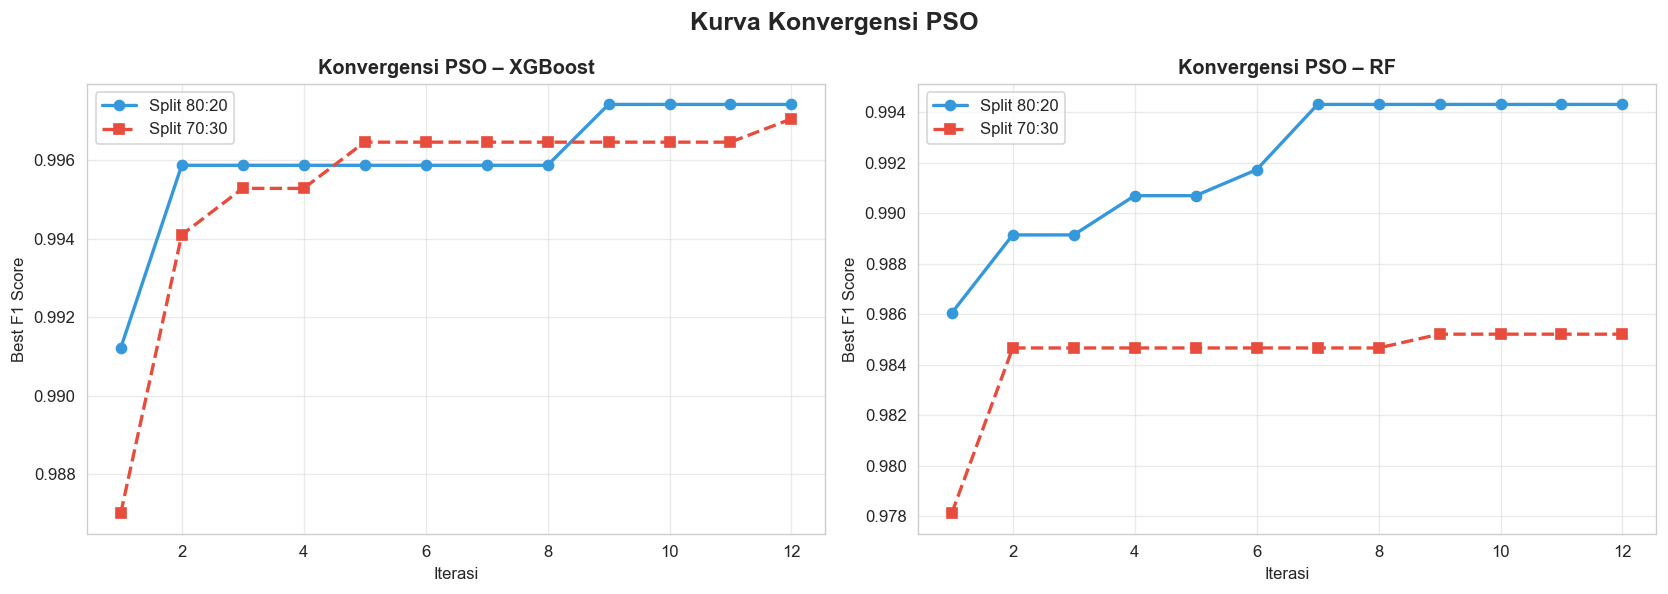

In [14]:
fig, axes = plt.subplots(1,2,figsize=(14,5))
for ax, (h80,h70,title) in zip(axes, [
    (xgb_hist_80,xgb_hist_70,'XGBoost'),
    (rf_hist_80,rf_hist_70,'RF')
]):
    ax.plot(range(1,len(h80)+1), h80, 'o-', color='#3498db', label='Split 80:20', lw=2, ms=6)
    ax.plot(range(1,len(h70)+1), h70, 's--', color='#e74c3c', label='Split 70:30', lw=2, ms=6)
    ax.set_title(f'Konvergensi PSO – {title}', fontweight='bold')
    ax.set_xlabel('Iterasi'); ax.set_ylabel('Best F1 Score'); ax.legend(); ax.grid(alpha=0.4)
plt.suptitle('Kurva Konvergensi PSO', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

## 5. Pemodelan & Evaluasi

### 5.1 Training Model dengan Hyperparameter Optimal

In [15]:
CLASS_NAMES = ['unacc','acc','good','vgood']

# XGBoost
xgb_model_80 = XGBClassifier(
    n_estimators=int(xgb_best_80[0]), max_depth=int(xgb_best_80[1]),
    learning_rate=float(xgb_best_80[2]), subsample=float(xgb_best_80[3]),
    colsample_bytree=float(xgb_best_80[4]), min_child_weight=float(xgb_best_80[5]),
    use_label_encoder=False, eval_metric='mlogloss', random_state=RANDOM_STATE, verbosity=0)
xgb_model_80.fit(X_train_80_bal, y_train_80_bal)

xgb_model_70 = XGBClassifier(
    n_estimators=int(xgb_best_70[0]), max_depth=int(xgb_best_70[1]),
    learning_rate=float(xgb_best_70[2]), subsample=float(xgb_best_70[3]),
    colsample_bytree=float(xgb_best_70[4]), min_child_weight=float(xgb_best_70[5]),
    use_label_encoder=False, eval_metric='mlogloss', random_state=RANDOM_STATE, verbosity=0)
xgb_model_70.fit(X_train_70_bal, y_train_70_bal)

# Random Forest
rf_model_80 = RandomForestClassifier(
    n_estimators      = int(round(rf_best_80[0])),
    max_depth         = int(round(rf_best_80[1])),
    min_samples_split = int(round(rf_best_80[2])),
    min_samples_leaf  = int(round(rf_best_80[3])),
    random_state      = RANDOM_STATE,
    n_jobs            = -1
)
rf_model_80.fit(X_train_80_bal, y_train_80_bal)

rf_model_70 = RandomForestClassifier(
    n_estimators      = int(round(rf_best_70[0])),
    max_depth         = int(round(rf_best_70[1])),
    min_samples_split = int(round(rf_best_70[2])),
    min_samples_leaf  = int(round(rf_best_70[3])),
    random_state      = RANDOM_STATE,
    n_jobs            = -1
)
rf_model_70.fit(X_train_70_bal, y_train_70_bal)


print('✅ Semua model berhasil dilatih!')
for name, m, Xte, yte in [
    ('XGBoost 80:20', xgb_model_80, X_test_80, y_test_80),
    ('XGBoost 70:30', xgb_model_70, X_test_70, y_test_70),
    ('RF     80:20', rf_model_80,  X_test_80, y_test_80),
    ('RF     70:30', rf_model_70,  X_test_70, y_test_70),
]:
    print(f'  {name} → Accuracy: {accuracy_score(yte, m.predict(Xte)):.4f}')

✅ Semua model berhasil dilatih!
  XGBoost 80:20 → Accuracy: 0.9827
  XGBoost 70:30 → Accuracy: 0.9865
  RF     80:20 → Accuracy: 0.9711
  RF     70:30 → Accuracy: 0.9557


### 5.2 Classification Report

In [16]:
for name, m, Xte, yte in [
    ('XGBoost | Split 80:20', xgb_model_80, X_test_80, y_test_80),
    ('XGBoost | Split 70:30', xgb_model_70, X_test_70, y_test_70),
    ('RF     | Split 80:20', rf_model_80,  X_test_80, y_test_80),
    ('RF     | Split 70:30', rf_model_70,  X_test_70, y_test_70),
]:
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(classification_report(yte, m.predict(Xte), target_names=CLASS_NAMES))


  XGBoost | Split 80:20
              precision    recall  f1-score   support

       unacc       1.00      1.00      1.00       242
         acc       0.97      0.97      0.97        77
        good       1.00      0.71      0.83        14
       vgood       0.81      1.00      0.90        13

    accuracy                           0.98       346
   macro avg       0.95      0.92      0.93       346
weighted avg       0.98      0.98      0.98       346


  XGBoost | Split 70:30
              precision    recall  f1-score   support

       unacc       1.00      1.00      1.00       363
         acc       0.97      0.99      0.98       115
        good       1.00      0.76      0.86        21
       vgood       0.90      0.95      0.93        20

    accuracy                           0.99       519
   macro avg       0.97      0.93      0.94       519
weighted avg       0.99      0.99      0.99       519


  RF     | Split 80:20
              precision    recall  f1-score   support

 

### 5.3 Confusion Matrix

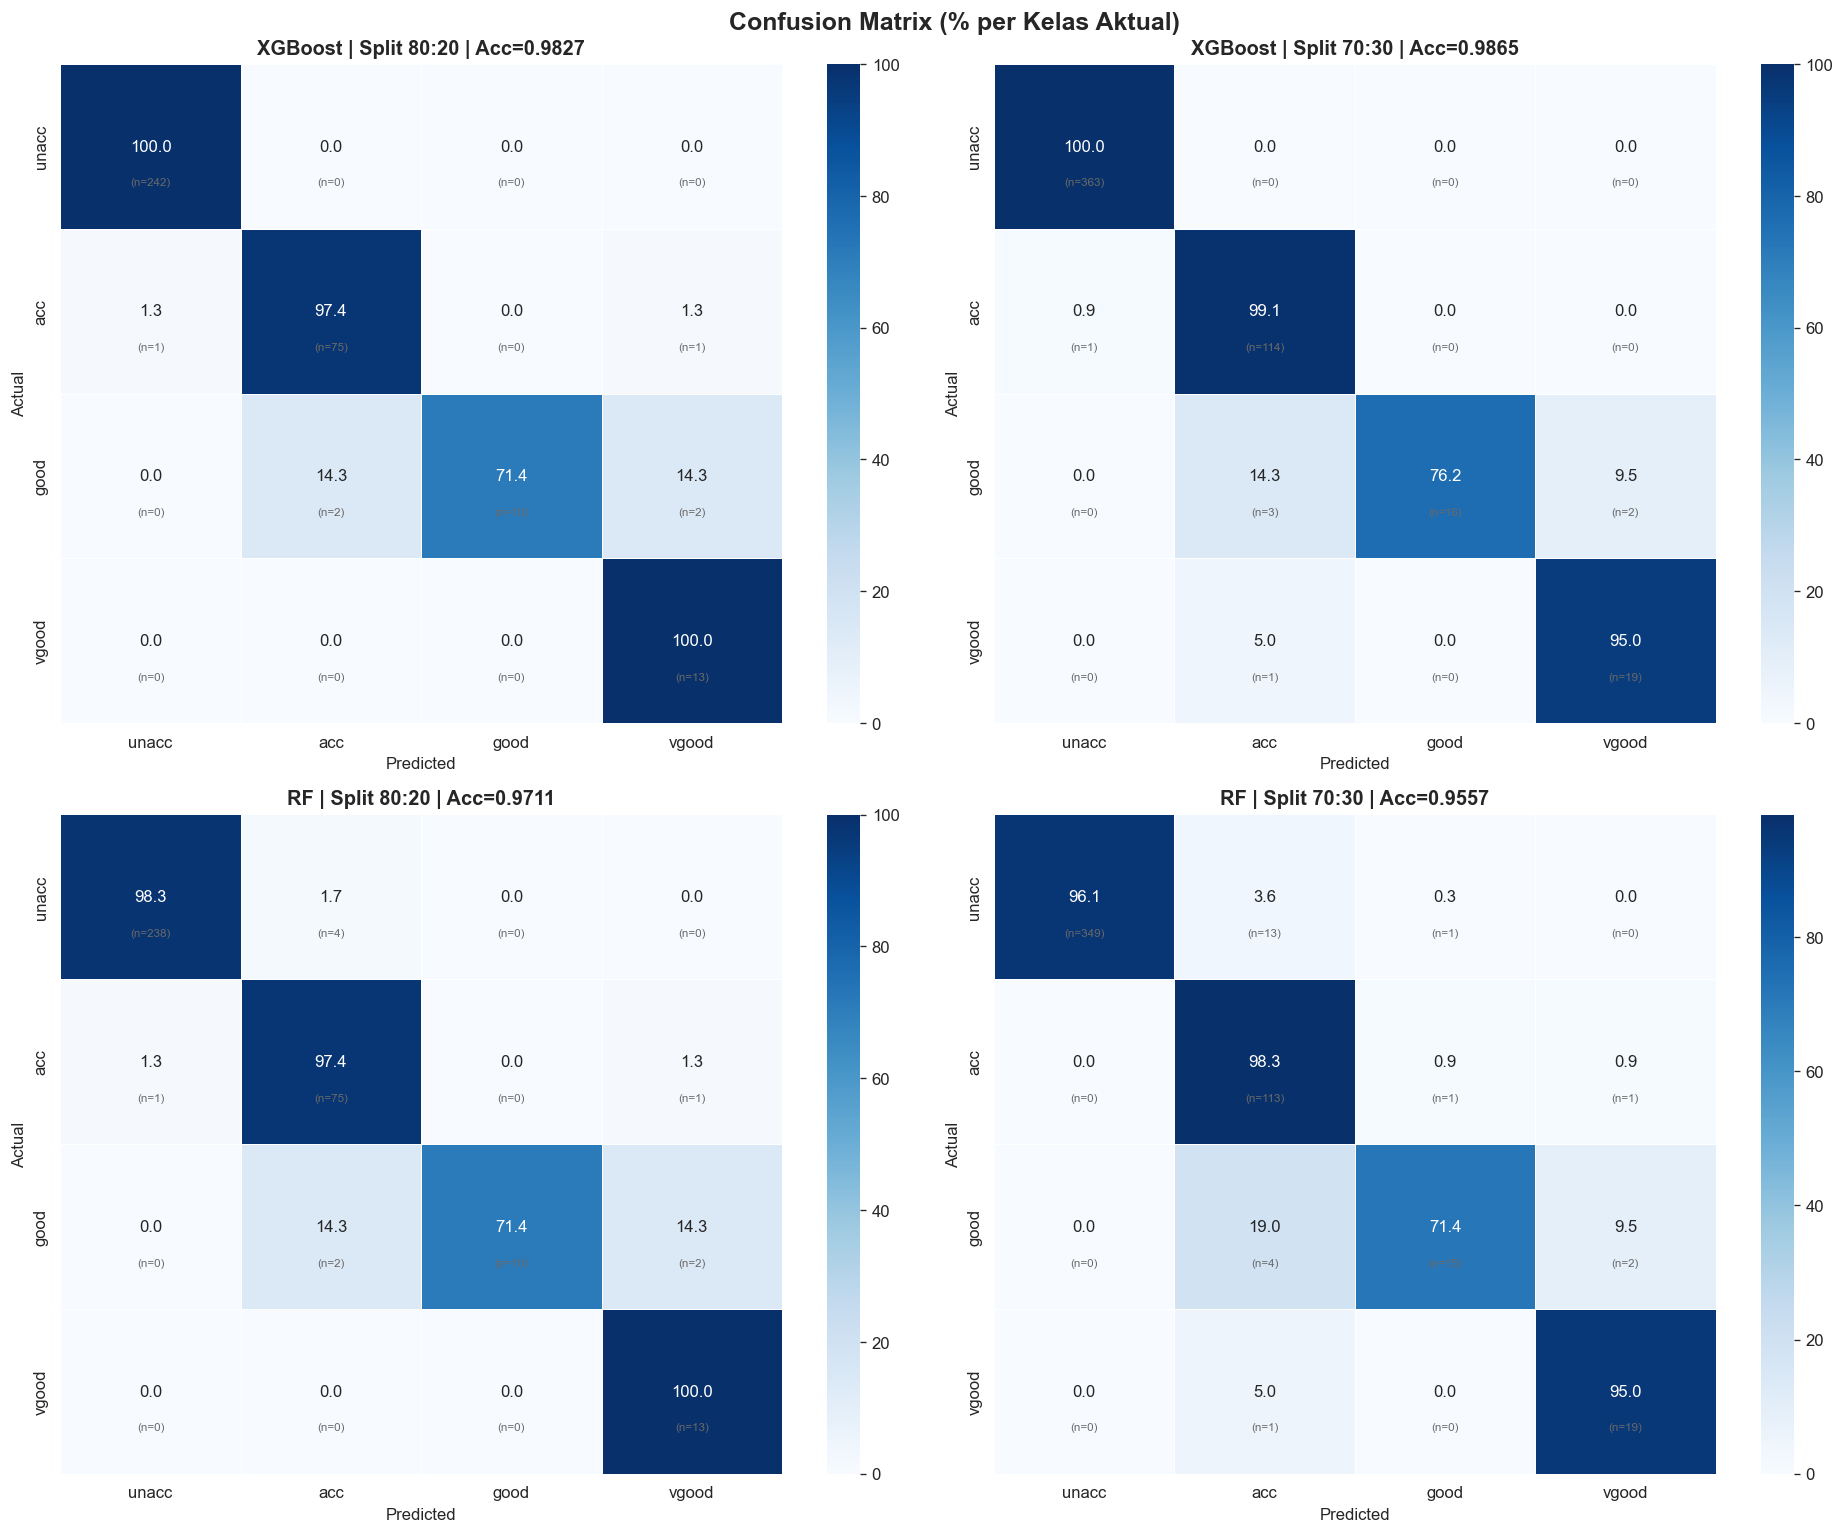

In [17]:
fig, axes = plt.subplots(2,2,figsize=(16,13))
axes = axes.flatten()

for ax, (name, m, Xte, yte, mlbl, slbl) in zip(axes, [
    ('XGBoost 80:20', xgb_model_80, X_test_80, y_test_80, 'XGBoost', '80:20'),
    ('XGBoost 70:30', xgb_model_70, X_test_70, y_test_70, 'XGBoost', '70:30'),
    ('RF 80:20',     rf_model_80,  X_test_80, y_test_80, 'RF',     '80:20'),
    ('RF 70:30',     rf_model_70,  X_test_70, y_test_70, 'RF',     '70:30'),
]):
    yp = m.predict(Xte)
    cm = confusion_matrix(yte, yp)
    cm_pct = cm.astype(float)/cm.sum(axis=1)[:,None]*100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.5)
    for i in range(4):
        for j in range(4):
            ax.text(j+0.5, i+0.72, f'(n={cm[i,j]})', ha='center', va='center', fontsize=7, color='dimgray')
    ax.set_title(f'{mlbl} | Split {slbl} | Acc={accuracy_score(yte,yp):.4f}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix (% per Kelas Aktual)', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

### 5.4 Feature Importance (XGBoost)

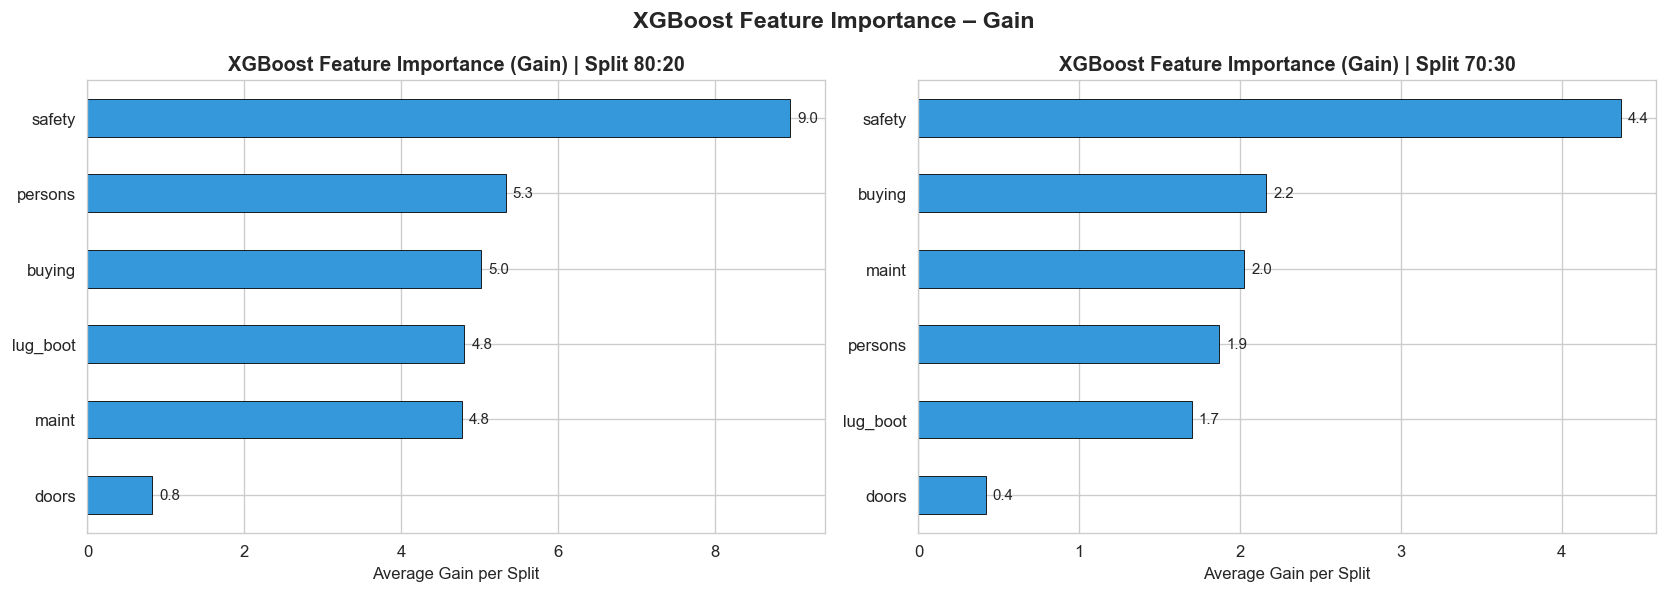

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (m, split) in zip(axes, [(xgb_model_80, '80:20'), (xgb_model_70, '70:30')]):
    # Gunakan 'gain' = rata-rata penurunan impurity per split
    gain_raw = m.get_booster().get_score(importance_type='gain')

    # XGBoost kadang beri nama 'f0','f1'... jika dilatih dengan array numpy
    # → petakan ke nama fitur asli
    mapped = {}
    for k, v in gain_raw.items():
        if k.startswith('f') and k[1:].isdigit():
            mapped[features[int(k[1:])]] = v   # 'f0' → features[0], dst.
        else:
            mapped[k] = v                       # nama sudah benar

    s = pd.Series(mapped).reindex(features).fillna(0).sort_values(ascending=True)
    s.plot(kind='barh', ax=ax, color='#3498db', edgecolor='black', lw=0.5)

    max_val = s.max() if s.max() > 0 else 1
    for i, v in enumerate(s.values):
        ax.text(v + max_val * 0.01, i, f'{v:.1f}', va='center', fontsize=9)

    ax.set_title(f'XGBoost Feature Importance (Gain) | Split {split}', fontweight='bold')
    ax.set_xlabel('Average Gain per Split')

plt.suptitle('XGBoost Feature Importance – Gain', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


### 5.5 Feature Importance (Random Forest)

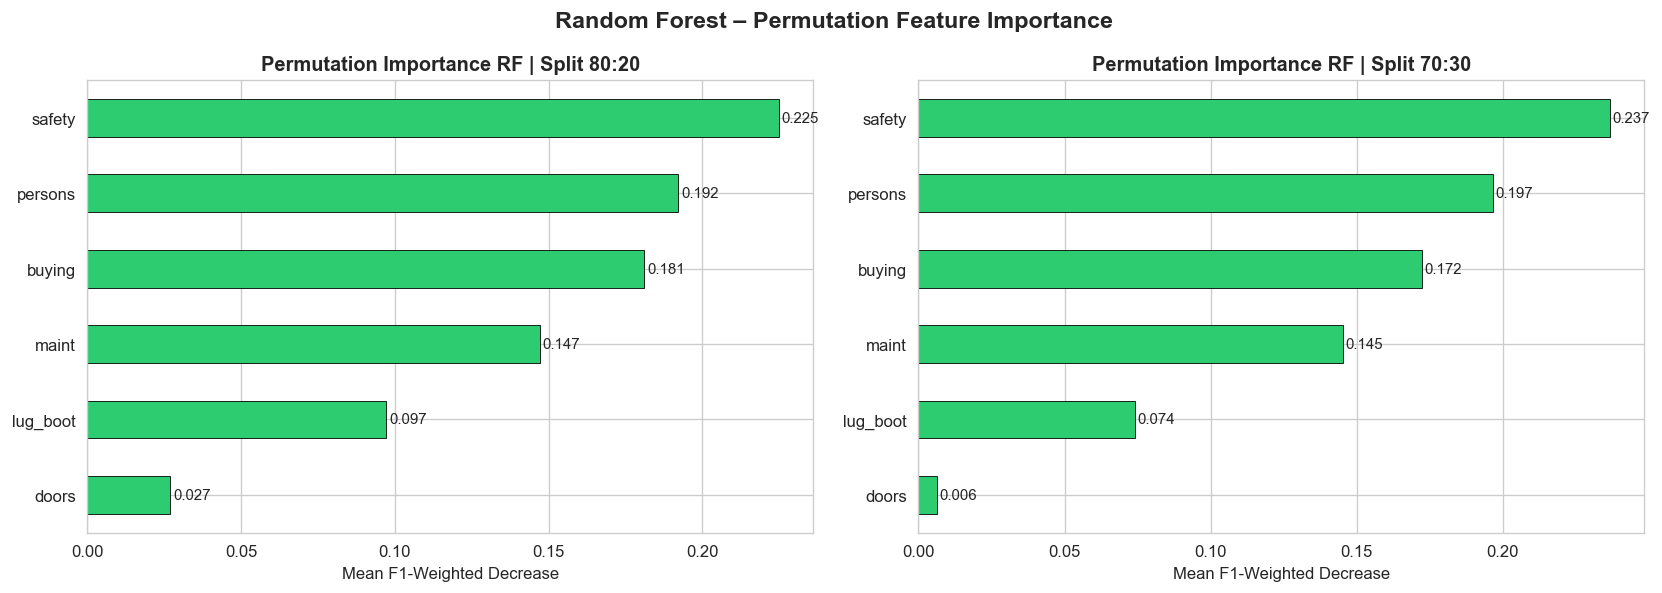

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (m, X_val, y_val, split) in zip(axes, [
    (rf_model_80, X_test_80, y_test_80, '80:20'),
    (rf_model_70, X_test_70, y_test_70, '70:30'),
]):
    result = permutation_importance(
        m, X_val, y_val,
        n_repeats    = 10,
        random_state = RANDOM_STATE,
        n_jobs       = -1,
        scoring      = 'f1_weighted'
    )
    s = pd.Series(result.importances_mean, index=features).sort_values(ascending=True)
    s.plot(kind='barh', ax=ax, color='#2ecc71', edgecolor='black', lw=0.5)
    for i, v in enumerate(s.values):
        ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)
    ax.set_title(f'Permutation Importance RF | Split {split}', fontweight='bold')
    ax.set_xlabel('Mean F1-Weighted Decrease')

plt.suptitle('Random Forest – Permutation Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


## 7. Perbandingan Hasil

In [20]:
results = {}
for name, m, Xte, yte in [
    ('XGBoost_80', xgb_model_80, X_test_80, y_test_80),
    ('XGBoost_70', xgb_model_70, X_test_70, y_test_70),
    ('RF_80',     rf_model_80,  X_test_80, y_test_80),
    ('RF_70',     rf_model_70,  X_test_70, y_test_70),
]:
    yp = m.predict(Xte)
    results[name] = {
        'Model' : 'XGBoost' if 'XGB' in name else 'RF',
        'Split' : '80:20' if '80' in name else '70:30',
        'Accuracy'    : accuracy_score(yte, yp),
        'F1 Weighted' : f1_score(yte, yp, average='weighted'),
        'F1 Macro'    : f1_score(yte, yp, average='macro'),
        'Precision'   : precision_score(yte, yp, average='weighted'),
        'Recall'      : recall_score(yte, yp, average='weighted'),
    }

df_res = pd.DataFrame(results).T
num_cols = ['Accuracy','F1 Weighted','F1 Macro','Precision','Recall']
df_res[num_cols] = df_res[num_cols].astype(float)
print("=== TABEL PERBANDINGAN PERFORMA ===")
print(df_res[['Model','Split']+num_cols].to_string())

=== TABEL PERBANDINGAN PERFORMA ===
              Model  Split  Accuracy  F1 Weighted  F1 Macro  Precision    Recall
XGBoost_80  XGBoost  80:20  0.982659     0.982147  0.925462   0.984297  0.982659
XGBoost_70  XGBoost  70:30  0.986513     0.985995  0.942215   0.986897  0.986513
RF_80            RF  80:20  0.971098     0.970831  0.917214   0.973544  0.971098
RF_70            RF  70:30  0.955684     0.956044  0.898318   0.959539  0.955684


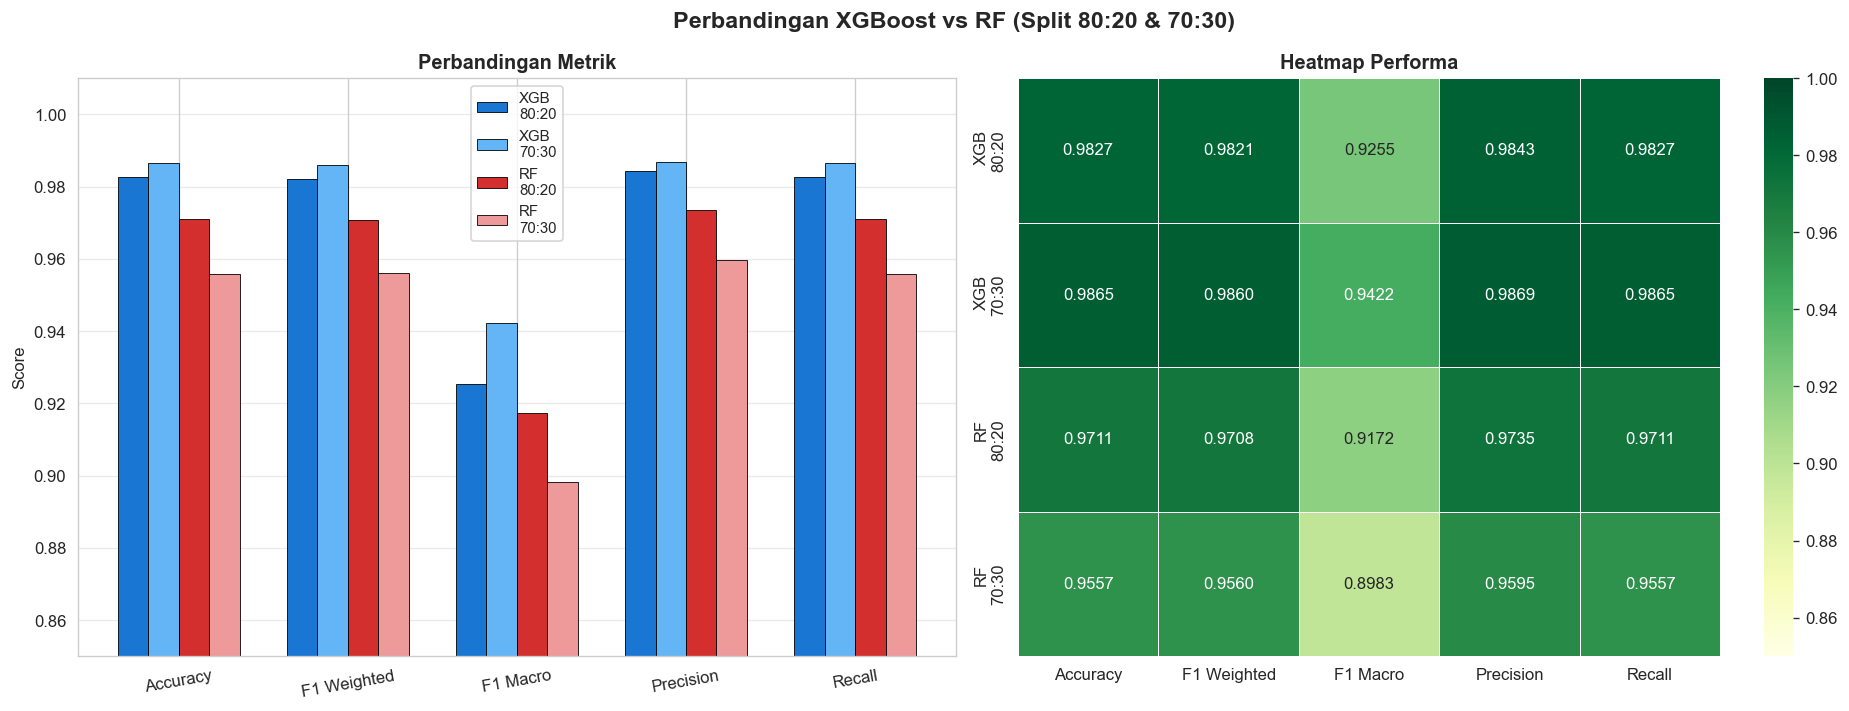

In [21]:
metrics = ['Accuracy','F1 Weighted','F1 Macro','Precision','Recall']
labels = ['XGB\n80:20','XGB\n70:30','RF\n80:20','RF\n70:30']
colors = ['#1976D2','#64B5F6','#D32F2F','#EF9A9A']
vals = [list(df_res.loc[k, metrics]) for k in df_res.index]

fig, axes = plt.subplots(1,2,figsize=(16,6))
x = np.arange(len(metrics)); w = 0.18
for i,(lbl,v,c) in enumerate(zip(labels,vals,colors)):
    axes[0].bar(x+i*w-1.5*w, v, w, label=lbl, color=c, edgecolor='black', lw=0.5)
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics, rotation=10)
axes[0].set_ylabel('Score'); axes[0].set_title('Perbandingan Metrik', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].set_ylim([0.85,1.01]); axes[0].grid(axis='y',alpha=0.4)

hm = pd.DataFrame(vals, index=labels, columns=metrics)
sns.heatmap(hm, annot=True, fmt='.4f', cmap='YlGn', ax=axes[1], vmin=0.85, vmax=1.0, linewidths=0.5)
axes[1].set_title('Heatmap Performa', fontweight='bold')
plt.suptitle('Perbandingan XGBoost vs RF (Split 80:20 & 70:30)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 7.1 PSO Hyperparameter Comparison

In [22]:
print('=== HYPERPARAMETER TERBAIK DARI PSO ===')
print('\n🔷 XGBoost:')
df_xgb = pd.DataFrame({
    'Split 80:20': {
        'n_estimators': int(xgb_best_80[0]), 'max_depth': int(xgb_best_80[1]),
        'learning_rate': round(float(xgb_best_80[2]),4),
        'subsample': round(float(xgb_best_80[3]),4),
        'colsample_bytree': round(float(xgb_best_80[4]),4),
        'min_child_weight': round(float(xgb_best_80[5]),2),
        'PSO_best_score': round(xgb_score_80,4)
    },
    'Split 70:30': {
        'n_estimators': int(xgb_best_70[0]), 'max_depth': int(xgb_best_70[1]),
        'learning_rate': round(float(xgb_best_70[2]),4),
        'subsample': round(float(xgb_best_70[3]),4),
        'colsample_bytree': round(float(xgb_best_70[4]),4),
        'min_child_weight': round(float(xgb_best_70[5]),2),
        'PSO_best_score': round(xgb_score_70,4)
    }
})
print(df_xgb)

print('\n🔷 RF:')
df_rf = pd.DataFrame({
    'Split 80:20': {'C': round(float(rf_best_80[0]),4), 'gamma': round(float(rf_best_80[1]),4),
                    'PSO_best_score': round(rf_score_80,4)},
    'Split 70:30': {'C': round(float(rf_best_70[0]),4), 'gamma': round(float(rf_best_70[1]),4),
                    'PSO_best_score': round(rf_score_70,4)},
})
print(df_rf)

=== HYPERPARAMETER TERBAIK DARI PSO ===

🔷 XGBoost:
                  Split 80:20  Split 70:30
n_estimators          90.0000     192.0000
max_depth              5.0000       5.0000
learning_rate          0.2495       0.2769
subsample              0.8701       0.7000
colsample_bytree       0.8451       0.7149
min_child_weight       1.0000       1.0700
PSO_best_score         0.9974       0.9970

🔷 RF:
                Split 80:20  Split 70:30
C                   60.3788      50.0000
gamma               17.5567      18.4750
PSO_best_score       0.9943       0.9852


## 8. Kesimpulan

In [23]:
print("="*60)
print("              KESIMPULAN ANALISIS")
print("="*60)

best_name = df_res[num_cols].astype(float)['Accuracy'].idxmax()
best = results[best_name]
print(f"\n🏆 MODEL TERBAIK: {best['Model']} | Split {best['Split']}")
print(f"   Accuracy   : {best['Accuracy']:.4f} ({best['Accuracy']*100:.2f}%)")
print(f"   F1 Weighted: {best['F1 Weighted']:.4f}")
print(f"   F1 Macro   : {best['F1 Macro']:.4f}")

print(f"\n📊 PERBANDINGAN SPLIT:")
for model_type in ['XGBoost', 'RF']:
    r80 = {k:v for k,v in results.items() if v['Model']==model_type and v['Split']=='80:20'}
    r70 = {k:v for k,v in results.items() if v['Model']==model_type and v['Split']=='70:30'}
    a80 = list(r80.values())[0]['Accuracy']
    a70 = list(r70.values())[0]['Accuracy']
    better = '80:20' if a80 > a70 else '70:30'
    print(f"   {model_type}: split {better} lebih baik (ΔAcc = {abs(a80-a70):.4f})")

print(f"\n🔬 TEMUAN UTAMA:")
print("  1. Dataset SANGAT TIDAK SEIMBANG (unacc 70%) → SMOTE berhasil menyeimbangkan")
print("  2. PSO efektif menemukan hyperparameter optimal tanpa exhaustive grid search")
print("  3. XGBoost dan Random Forest keduanya stabil")
print("  4. Fitur 'safety' paling berpengaruh pada kedua model")
print(f"  5. {best['Model']} split {best['Split']} mencapai akurasi tertinggi")
print("="*60)

              KESIMPULAN ANALISIS

🏆 MODEL TERBAIK: XGBoost | Split 70:30
   Accuracy   : 0.9865 (98.65%)
   F1 Weighted: 0.9860
   F1 Macro   : 0.9422

📊 PERBANDINGAN SPLIT:
   XGBoost: split 70:30 lebih baik (ΔAcc = 0.0039)
   RF: split 80:20 lebih baik (ΔAcc = 0.0154)

🔬 TEMUAN UTAMA:
  1. Dataset SANGAT TIDAK SEIMBANG (unacc 70%) → SMOTE berhasil menyeimbangkan
  2. PSO efektif menemukan hyperparameter optimal tanpa exhaustive grid search
  3. XGBoost dan Random Forest keduanya stabil
  4. Fitur 'safety' paling berpengaruh pada kedua model
  5. XGBoost split 70:30 mencapai akurasi tertinggi
